<a href="https://colab.research.google.com/github/mlnjsh/Introduction-to-Deep-Learning/blob/main/notebooks_DeepLearning/02_optimizers_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02. Comparing Optimizers — Keras

The optimizer decides *how* weights move down the loss surface. We hold the architecture fixed and swap only the optimizer: **SGD, SGD+Momentum, RMSprop, Adam, Adagrad**.

**Dataset:** `loan_prediction_data.csv` — 614 loan applications, 11 pre-normalised features, binary target `Loan_Status` (1 = approved).

---

## 1. Setup & imports

In [3]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
keras.utils.set_random_seed(42)          # reproducible weights + shuffling
print("TensorFlow", tf.__version__, "| Keras", keras.__version__)

TensorFlow 2.20.0 | Keras 3.13.2


## 2. Load the data

In [4]:
import os, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split

# Robust load: works whether the notebook runs from its own folder or the parent
CSV = "loan_prediction_data.csv"
if not os.path.exists(CSV):
    CSV = os.path.join("..", "loan_prediction_data.csv")

df = pd.read_csv(CSV)
print("Shape:", df.shape)
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,0.0,0.0,0.000000,1.0,0.0,0.070489,0.000000,0.198860,0.74359,1.0,1.0,1.0
1,LP001003,0.0,1.0,0.333333,1.0,0.0,0.054830,0.036192,0.172214,0.74359,1.0,0.0,0.0
2,LP001005,0.0,1.0,0.000000,1.0,1.0,0.035250,0.000000,0.082489,0.74359,1.0,1.0,1.0
3,LP001006,0.0,1.0,0.000000,0.0,0.0,0.030093,0.056592,0.160637,0.74359,1.0,1.0,1.0
4,LP001008,0.0,0.0,0.000000,1.0,0.0,0.072356,0.000000,0.191027,0.74359,1.0,1.0,1.0


## 3. Prepare features & train/test split

The features are already scaled to `[0,1]`, so we only drop the ID and split. We use a **stratified** split so the approval rate matches in train and test.

In [5]:
# Features are ALREADY normalised to [0,1] in this dataset, so no scaling needed.
# Drop the ID column and separate the target.
X = df.drop(columns=["Loan_ID", "Loan_Status"]).values.astype("float32")
y = df["Loan_Status"].values.astype("float32")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
N_FEATURES = X_train.shape[1]
print("Train:", X_train.shape, " Test:", X_test.shape, " Features:", N_FEATURES)
print("Train positive rate: %.3f  Test positive rate: %.3f" % (y_train.mean(), y_test.mean()))

Train: (491, 11)  Test: (123, 11)  Features: 11
Train positive rate: 0.686  Test positive rate: 0.691


In [6]:
def plot_history(hist, title=""):
    """Plot train (solid) vs test/val (dashed) loss and accuracy over epochs."""
    h = hist.history
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(h["loss"], label="train")
    ax[0].plot(h["val_loss"], "--", label="test")
    ax[0].set_title(title + " — Loss"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
    ax[0].legend(); ax[0].grid(alpha=.3)
    ax[1].plot(h["accuracy"], label="train")
    ax[1].plot(h["val_accuracy"], "--", label="test")
    ax[1].set_title(title + " — Accuracy"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
    ax[1].legend(); ax[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

## 4. One model, many optimizers

`build_and_train` rebuilds the *same* architecture from the *same* seed each time, so any difference in the curves is due purely to the optimizer.

In [7]:
def build_and_train(optimizer, epochs=100):
    keras.utils.set_random_seed(42)      # identical starting weights every run
    model = keras.Sequential([
        keras.Input(shape=(N_FEATURES,)),
        layers.Dense(16, activation="relu"),
        layers.Dense(1,  activation="sigmoid"),
    ])
    model.compile(optimizer=optimizer, loss="binary_crossentropy", metrics=["accuracy"])
    hist = model.fit(X_train, y_train, validation_data=(X_test, y_test),
                     epochs=epochs, batch_size=32, verbose=0)
    return model, hist

optimizers = {
    "SGD":          keras.optimizers.SGD(learning_rate=0.01),
    "SGD+Momentum": keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    "RMSprop":      keras.optimizers.RMSprop(learning_rate=0.01),
    "Adam":         keras.optimizers.Adam(learning_rate=0.01),
    "Adagrad":      keras.optimizers.Adagrad(learning_rate=0.01),
}

results = {}
for name, opt in optimizers.items():
    _, hist = build_and_train(opt)
    results[name] = hist
    print("%-14s final test acc = %.3f | test loss = %.3f" %
          (name, hist.history["val_accuracy"][-1], hist.history["val_loss"][-1]))

SGD            final test acc = 0.846 | test loss = 0.485
SGD+Momentum   final test acc = 0.862 | test loss = 0.403
RMSprop        final test acc = 0.862 | test loss = 0.401
Adam           final test acc = 0.837 | test loss = 0.410
Adagrad        final test acc = 0.854 | test loss = 0.466


## 5. Comparison table

In [8]:
summary = pd.DataFrame({
    name: {
        "final_train_acc": h.history["accuracy"][-1],
        "final_test_acc":  h.history["val_accuracy"][-1],
        "final_test_loss": h.history["val_loss"][-1],
        "best_test_acc":   max(h.history["val_accuracy"]),
    } for name, h in results.items()
}).T.sort_values("best_test_acc", ascending=False)
summary.round(4)

,final_train_acc,final_test_acc,final_test_loss,best_test_acc
SGD+Momentum,0.7963,0.8618,0.4031,0.8618
Adam,0.8187,0.8374,0.4102,0.8618
RMSprop,0.8086,0.8618,0.4008,0.8618
Adagrad,0.7984,0.8537,0.4661,0.8537
SGD,0.7902,0.8455,0.4847,0.8455


## 6. Overlaid learning curves

All optimizers on one axis — the fast, smooth ones reach low loss in fewer epochs.

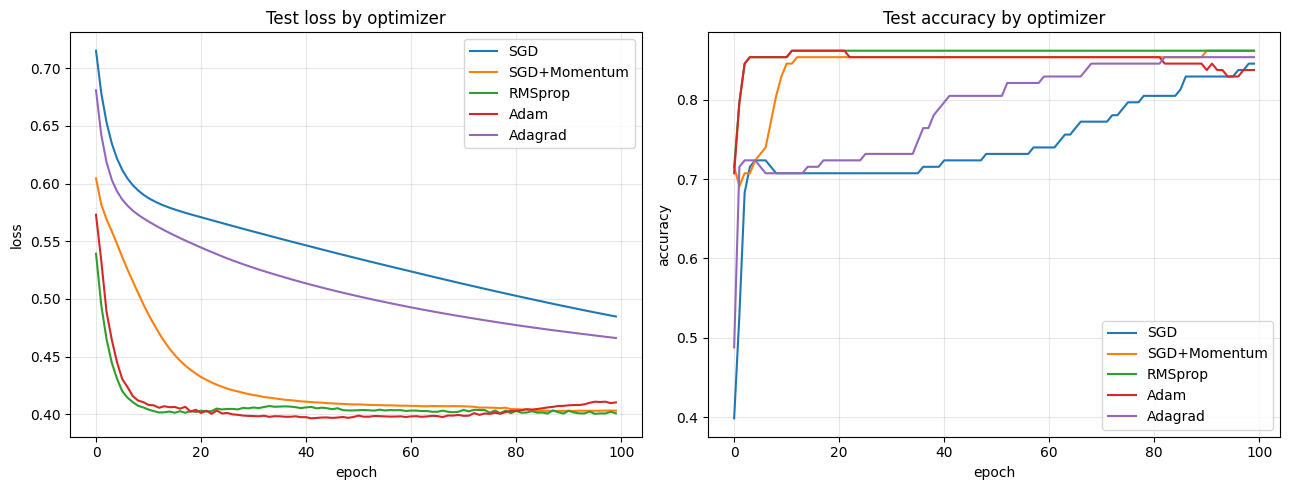

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for name, h in results.items():
    ax[0].plot(h.history["val_loss"], label=name)
    ax[1].plot(h.history["val_accuracy"], label=name)
ax[0].set_title("Test loss by optimizer"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
ax[1].set_title("Test accuracy by optimizer"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
for a in ax: a.legend(); a.grid(alpha=.3)
plt.tight_layout(); plt.show()

## Takeaways
- **Plain SGD** is the slowest to converge — it takes many epochs to reach the loss the adaptive methods hit early.
- **Momentum** accelerates SGD by accumulating a velocity term, smoothing the descent.
- **Adam / RMSprop** adapt a per-parameter learning rate and usually converge fastest on small tabular data — at the risk of a noisier test curve.
- There is no universal winner: the *best* optimizer depends on the problem. Comparing them (as above) is the point.
- **Next:** `03_weight_init_keras` — before the optimizer even starts, *where* the weights begin matters.